# Vanishing Gradient Demonstration


## Step 1: Generate a non-linear dataset (make_moons)
- Purpose: create a simple 2D classification task that needs non-linear decision boundaries.
- Why: ideal for visualizing learning behavior and decision difficulty.
- Expected outcome: `X` with shape (300, 2) and `y` binary labels.

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from keras.layers import Dense
from keras.models import Sequential

# Generate non-linear dataset
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)


## Step 2: Visualize the data
- Purpose: confirm the two interleaving moon shapes.
- Why: ensures the task is non-linear and needs more than a linear separator.
- Expected outcome: a scatter plot colored by class.

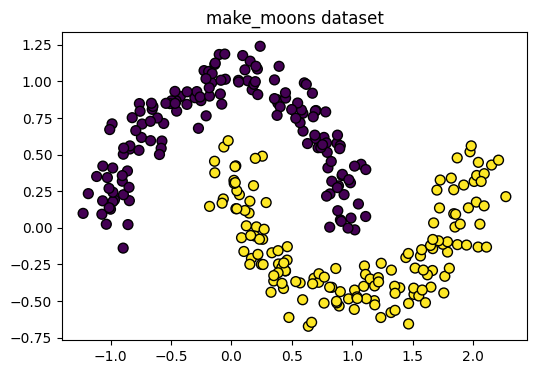

In [42]:
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', s=50, edgecolors='k')
plt.title('make_moons dataset')
plt.show()

## Step 3: Build a deep sigmoid network (intentionally hard to train)
- Purpose: stack many sigmoid layers to trigger vanishing gradients.
- Why: sigmoid saturates; its derivative is small, so gradients shrink across layers.
- Math: sigmoid derivative $\sigma'(z) = \sigma(z)(1-\sigma(z)) \le 0.25$.
- Chain rule intuition: gradients multiply across layers, so $\prod_l \sigma'(z_l)$ becomes tiny.
- Expected outcome: a deep model that often learns slowly or stalls.

In [43]:
# Build a 10-layer sigmoid network
model_sig = Sequential()
model_sig.add(Dense(10, activation='sigmoid', input_dim=2))
for _ in range(8):
    model_sig.add(Dense(10, activation='sigmoid'))
model_sig.add(Dense(1, activation='sigmoid'))

model_sig.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_sig.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 921 (3.60 KB)

 Trainable params: 921 (3.60 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Split data before training
- Purpose: hold out test data for evaluation.
- Why: we want to study optimization behavior on train, but still keep a clean test set.
- Expected outcome: `X_train`, `X_test`, `y_train`, `y_test`.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## Step 5: Train and observe loss
- Purpose: fit the deep sigmoid model.
- Why: vanishing gradients often show up as a flat or slow-decreasing loss curve.
- Expected outcome: training logs showing limited improvement.
- Tip: capture `history = model.fit(...)` and plot `history.history['loss']` to visualize stalling.

In [45]:
model_sig.layers[0].get_weights()

[array([[-0.02698308,  0.5730397 , -0.38528287, -0.30751908, -0.06527132,
         -0.0471974 , -0.01155347,  0.09130692,  0.01980263, -0.16088396],
        [-0.67988026, -0.6788984 ,  0.4312808 , -0.68391824,  0.23023611,
          0.26599753,  0.6634374 ,  0.6729943 , -0.21893954, -0.5495651 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)]

In [46]:
old_weights_sig = model_sig.layers[0].get_weights()[0]
print(old_weights_sig)

[[-0.02698308  0.5730397  -0.38528287 -0.30751908 -0.06527132 -0.0471974
  -0.01155347  0.09130692  0.01980263 -0.16088396]
 [-0.67988026 -0.6788984   0.4312808  -0.68391824  0.23023611  0.26599753
   0.6634374   0.6729943  -0.21893954 -0.5495651 ]]


In [47]:
history_sig = model_sig.fit(X_train, y_train, epochs=150, verbose=1, validation_data=(X_test, y_test))

Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.4833 - loss: 0.6975 - val_accuracy: 0.5667 - val_loss: 0.6878
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4833 - loss: 0.6956 - val_accuracy: 0.5667 - val_loss: 0.6895
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4833 - loss: 0.6946 - val_accuracy: 0.5667 - val_loss: 0.6916
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4833 - loss: 0.6938 - val_accuracy: 0.5667 - val_loss: 0.6931
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5250 - loss: 0.6932 - val_accuracy: 0.4333 - val_loss: 0.6940
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5167 - loss: 0.6931 - val_accuracy: 0.4333 - val_loss: 0.6940
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5167 - loss: 0.6929 - val_accuracy: 0.4333 - val_loss: 0.6951
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5167 - loss: 0.6927 - val_accuracy: 0.4333 - val_loss

In [48]:
model_sig.layers[0].get_weights()

[array([[ 0.21103303,  0.6627278 , -0.5535424 ,  0.21481675, -0.32582548,
         -0.21641637, -0.33592147, -0.3636324 , -0.14726809,  0.15874535],
        [-1.8930755 , -2.1414921 ,  1.8047552 , -2.1625507 ,  1.5064938 ,
          1.3815305 ,  2.028571  ,  2.1734357 ,  0.90118086, -1.8082271 ]],
       dtype=float32),
 array([ 1.42137140e-01, -2.43168883e-02, -1.77531096e-04,  2.10391805e-01,
        -7.16248974e-02, -1.21927150e-01, -1.69054121e-01, -1.73939511e-01,
         1.17467735e-02,  1.45313695e-01], dtype=float32)]

In [49]:
new_weights_sig = model_sig.layers[0].get_weights()[0]
print(old_weights_sig)
print('-'*50)
print(new_weights_sig)

[[-0.02698308  0.5730397  -0.38528287 -0.30751908 -0.06527132 -0.0471974
  -0.01155347  0.09130692  0.01980263 -0.16088396]
 [-0.67988026 -0.6788984   0.4312808  -0.68391824  0.23023611  0.26599753
   0.6634374   0.6729943  -0.21893954 -0.5495651 ]]
--------------------------------------------------
[[ 0.21103303  0.6627278  -0.5535424   0.21481675 -0.32582548 -0.21641637
  -0.33592147 -0.3636324  -0.14726809  0.15874535]
 [-1.8930755  -2.1414921   1.8047552  -2.1625507   1.5064938   1.3815305
   2.028571    2.1734357   0.90118086 -1.8082271 ]]


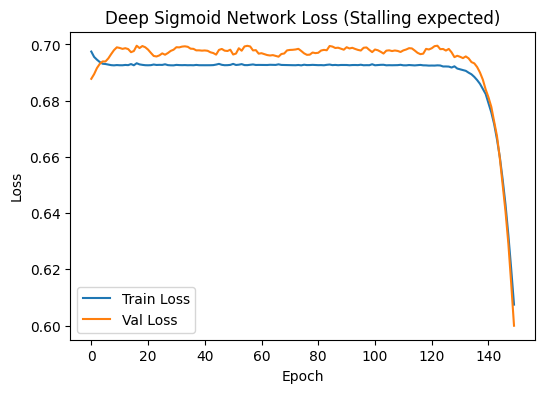

In [50]:
plt.figure(figsize=(6,4))
plt.plot(history_sig.history['loss'], label='Train Loss')
plt.plot(history_sig.history['val_loss'], label='Val Loss')
plt.title('Deep Sigmoid Network Loss (Stalling expected)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Step 6: Diagnose weight updates (proxy for vanishing gradients)
- Purpose: compare weights before and after training in early layers.
- Why: if gradients vanish, early-layer weights change very little.
- Note: `old_weights - new_weights` is not the exact gradient with Adam, but it is a practical update proxy.
- Expected outcome: very small deltas for the first layer when using deep sigmoid.

In [51]:
# Calculate the absolute difference in weights
weight_diff_sig = np.abs(old_weights_sig - new_weights_sig)
print('Maximum weight change in Layer 1 (Sigmoid):', np.max(weight_diff_sig))
print('Average weight change in Layer 1 (Sigmoid):', np.mean(weight_diff_sig))



Maximum weight change in Layer 1 (Sigmoid): 1.5004413
Average weight change in Layer 1 (Sigmoid): 0.79390615


## Step 7: Solution 1 - Replace sigmoid with ReLU
- Purpose: build a deep network with ReLU activations.
- Why: ReLU derivative is 1 for positive inputs, which reduces gradient shrinkage.
- Math: $\text{ReLU}(z) = \max(0, z)$, so gradients do not saturate for $z > 0$.
- Expected outcome: larger weight updates and improved loss decrease.

In [52]:
# Build the exact same network but with ReLU
model_relu = Sequential()
model_relu.add(Dense(10, activation='relu', input_dim=2))
for _ in range(8):
    model_relu.add(Dense(10, activation='relu'))
model_relu.add(Dense(1, activation='sigmoid')) # Last layer is still sigmoid for binary classification

model_relu.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## Step 8: Train the ReLU model and compare
- Purpose: verify that loss decreases faster and weight updates are larger.
- Why: demonstrates a concrete remedy for vanishing gradients.
- Expected outcome: better optimization behavior than deep sigmoid.

In [53]:
model_relu.layers[0].get_weights()

[array([[ 0.49828905,  0.12123525,  0.3430919 , -0.16177326, -0.62199104,
         -0.2829397 , -0.68200326,  0.11567187,  0.13941908, -0.27625978],
        [ 0.28273672, -0.23125789, -0.44085047,  0.39895397,  0.46388775,
         -0.47527987, -0.26436645, -0.36833292, -0.5266147 , -0.5975101 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)]

In [54]:
old_weights_relu = model_relu.layers[0].get_weights()[0]
print(old_weights_relu)


[[ 0.49828905  0.12123525  0.3430919  -0.16177326 -0.62199104 -0.2829397
  -0.68200326  0.11567187  0.13941908 -0.27625978]
 [ 0.28273672 -0.23125789 -0.44085047  0.39895397  0.46388775 -0.47527987
  -0.26436645 -0.36833292 -0.5266147  -0.5975101 ]]


In [55]:
history_relu = model_relu.fit(X_train, y_train, epochs=100, verbose=1, validation_data=(X_test, y_test))





Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 413ms/step - accuracy: 0.4792 - loss: 0.6899 - val_accuracy: 0.7333 - val_loss: 0.6813
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6917 - loss: 0.6804 - val_accuracy: 0.7833 - val_loss: 0.6651
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7500 - loss: 0.6654 - val_accuracy: 0.8000 - val_loss: 0.6368
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8042 - loss: 0.6439 - val_accuracy: 0.9167 - val_loss: 0.5989
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8500 - loss: 0.6154 - val_accuracy: 0.9167 - val_loss: 0.5514
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8500 - loss: 0.5811 - val_accuracy: 0.9167 - val_loss: 0.4986
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8542 - loss: 0.5470 - val_accuracy: 0.9167 - val_loss: 0.4462
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8625 - loss: 0.5139 - val_accuracy: 0.9167 - val_loss

In [56]:
model_relu.layers[0].get_weights()

[array([[ 0.5620493 ,  0.13852197,  0.4147352 , -0.19417122, -0.59685916,
         -0.40803608, -0.6550538 ,  0.10479747,  0.25569263, -0.37040195],
        [ 0.36985517, -0.33627594, -0.49403083,  0.42263982,  0.47350305,
         -0.32418856, -0.30257553, -0.42796654, -0.3523656 , -0.4867235 ]],
       dtype=float32),
 array([ 0.02241281, -0.01755008, -0.04220757, -0.14734706,  0.21939255,
        -0.01865182, -0.00354651, -0.08314243, -0.07302019, -0.06682643],
       dtype=float32)]

In [57]:
new_weights_relu = model_relu.layers[0].get_weights()[0]
print(old_weights_relu)
print('-'*50)
print(new_weights_relu)

[[ 0.5620493   0.13852197  0.4147352  -0.19417122 -0.59685916 -0.40803608
  -0.6550538   0.10479747  0.25569263 -0.37040195]
 [ 0.36985517 -0.33627594 -0.49403083  0.42263982  0.47350305 -0.32418856
  -0.30257553 -0.42796654 -0.3523656  -0.4867235 ]]


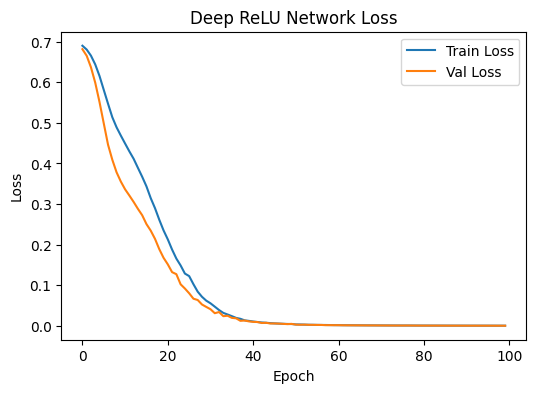

In [58]:

plt.figure(figsize=(6,4))
plt.plot(history_relu.history['loss'], label='Train Loss')
plt.plot(history_relu.history['val_loss'], label='Val Loss')
plt.title('Deep ReLU Network Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [59]:
weight_diff_relu = np.abs(old_weights_relu - new_weights_relu)
print('Maximum weight change in Layer 1 (ReLU):', np.max(weight_diff_relu))
print('Average weight change in Layer 1 (ReLU):', np.mean(weight_diff_relu))

Maximum weight change in Layer 1 (ReLU): 0.17424911
Average weight change in Layer 1 (ReLU): 0.06980719
